# Clusters 

Esta es una biblioteca simple para mostrar las capacidades de Nbdev. 

La biblioteca va a generar clusters y vamos a utilizar algoritmos de clusterización para ver si los podemos encontrar. 

In [1]:
#| default_exp cluster_ejemplo

In [2]:
#| hide 
#| export
import matplotlib
import sklearn
import random
import numpy as np
import shapely
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS, KMeans
import matplotlib.pyplot as plt
from nbdev.showdoc import *

In [3]:
#| export

class data_points:
    """Una clase que contiene a los datos"""
    def __init__(self, n, min_x = 0, min_y = 0, max_x= 1, max_y=1, seed= None):
        if seed != None:
            random.seed(seed)
        
        self.Points = np.random.uniform(low= min_x, high= max_x, size=(n, 2));
        self.Points =  [shapely.Point(x[0],x[1]) for x in self.Points]

    
    def get_points(self):
        """Una funcion que para obtener los puntos"""
        return self.Points

    def get_Multypoint(self):
        """Regresa un objeto MultiPoint con los puntos"""
        return shapely.geometry.MultiPoint(self.Points)
    
    def get_X(self):
        """Regresa las coordenadas X"""
        return [x.x for x in self.Points]

    def get_Y(self):
        """Regresa las coordenadas Y"""
        return [x.y for x in self.Points]

    def centroid(self):
        """Regresa el centroide de los puntos """
        return shapely.centroid(self.get_Multypoint())

    def as_array(self):
        """Regresa los puntos como un array"""
        list_arrays = np.array([(geom.xy[0][0], geom.xy[1][0]) for geom in self.Points])
        return list_arrays

    def add_points(self, data_points):
        """Agrega puntos de otra """
        self.Points = self.Points + data_points.Points
        return

In [4]:
#| hide 
puntos_simples = data_points(n= 500)
puntos_simples.centroid()
puntos_simples.get_points()
puntos_simples.get_Multypoint()
puntos_simples.get_X()
puntos_simples.get_Y()



if len(puntos_simples.get_X()) != len(puntos_simples.get_Y()):
    raise Exception("Si hay problema la evaluacion ")

## Clusters 

Esta es una clase que utilizamos para agrupar puntos en 2D

A partir de los puntos vamos a generar clusters (agrupamientos) y vamos a vizualizarlos haiendo uso de **Matplotlib**

In [5]:
#| export 
class Clusters:
  """
  Clase para generar los clusters a partir de un objeto de la clase data_points
  
  Esta clase se utiliza para generar los distintos tipos de clusterizaciones, 
  se almacena los datos en una estructura de datos y se le añaden las respectivas 
  classes
  """
    
  def __init__(self, data_points_i, seed=1234):
    if seed != None:
      random.seed(seed)
      self.data_structure =  data_points_i
    
  def KMeans(self, **kwargs):
    """
    Se usa el algoritmo Kmeans para la obtencion de clusters, 
    las clases quedan almacenadas en .data_structure_classes_Kmeans.
    Si se desea obtener el modelo se tiene que añadir 
    (ret_model = True) como parámetro.
    """
    kmeans_c = KMeans(**kwargs)
    classes_val = kmeans_c.fit_predict(self.data_structure.as_array())
    self.data_structure.classes_Kmeans = classes_val
    
    if 'ret_model' in kwargs and kwargs['ret_model']==True :
        return  kmeans_c
        

  def DBSCAN(self, **kwargs):
    """
    Se DBSCAN para la obtencion de clusters, las clases quedan almacenadas
    en .data_structure_classes_DBSCAN. Si se desea obtener el modelo se tiene
    que añadir (ret_model = True) como parámetro.
    """
    db = DBSCAN(**kwargs).fit(self.data_structure.as_array())
    self.data_structure.classes_DBSCAN = db.labels_
    if 'ret_model' in kwargs and kwargs['ret_model']==True :
        return  db
    
    
  def HDBSCAN(self, **kwargs):
    """
    Se HDBSCAN para la obtencion de clusters, las clases quedan almacenadas
    en .data_structure_classes_HDBSCAN. Si se desea obtener el modelo se tiene
    que añadir (ret_model = True) como parámetro.
    """
    hdb = HDBSCAN(**kwargs).fit(self.data_structure.as_array())
    self.data_structure.classes_HDBSCAN = hdb.labels_
    if 'ret_model' in kwargs and kwargs['ret_model']==True : 
      return  hdb
        

  def OPTICS(self, **kwargs):
    """
    Se usa el algoritmo OPTICS para la obtencion de clusters, 
    las clases quedan almacenadas en .data_structure_classes_OPTICS.
    Si se desea obtener el modelo se tiene que añadir 
    (ret_model = True) como parámetro.
    """
    optics=  OPTICS(**kwargs).fit(self.data_structure.as_array())
    self.data_structure.classes_OPTICS = optics.labels_
    
    if 'ret_model' in kwargs and kwargs['ret_model']==True :
        return  optics

In [6]:
show_doc(Clusters.DBSCAN)

---

### Clusters.DBSCAN

```python

def DBSCAN(
    kwargs:VAR_KEYWORD
):


```

*Se DBSCAN para la obtencion de clusters, las clases quedan almacenadas*
en .data_structure_classes_DBSCAN. Si se desea obtener el modelo se tiene
que añadir (ret_model = True) como parámetro.

In [7]:
show_doc(Clusters.HDBSCAN)

---

### Clusters.HDBSCAN

```python

def HDBSCAN(
    kwargs:VAR_KEYWORD
):


```

*Se HDBSCAN para la obtencion de clusters, las clases quedan almacenadas*
en .data_structure_classes_HDBSCAN. Si se desea obtener el modelo se tiene
que añadir (ret_model = True) como parámetro.

In [8]:
show_doc(Clusters.OPTICS)

---

### Clusters.OPTICS

```python

def OPTICS(
    kwargs:VAR_KEYWORD
):


```

*Se usa el algoritmo OPTICS para la obtencion de clusters, *
las clases quedan almacenadas en .data_structure_classes_OPTICS.
Si se desea obtener el modelo se tiene que añadir 
(ret_model = True) como parámetro.

In [9]:
show_doc(Clusters.KMeans)

---

### Clusters.KMeans

```python

def KMeans(
    kwargs:VAR_KEYWORD
):


```

*Se usa el algoritmo Kmeans para la obtencion de clusters, *
las clases quedan almacenadas en .data_structure_classes_Kmeans.
Si se desea obtener el modelo se tiene que añadir 
(ret_model = True) como parámetro.

## Ejemplo sencillo 

Este ejemplo muestra el uso combinado de las clases `Cluster` y `data_points`



In [10]:
datos_simples_3 = data_points(500, min_x = 0.6, min_y= 0.6, max_x= 1.0, max_y= 1.0 )
datos_simples_2 = data_points(500, min_x = 0.0, min_y= 0.6, max_x= 0.4, max_y= 1.0 )
datos_simples_1 = data_points(500, min_x = 0.6, min_y= 0.0, max_x= 1.0, max_y= 0.4 )
datos_simples_0 = data_points(500, min_x = 0.0, min_y= 0.0, max_x= 0.4, max_y= 0.4 )

In [11]:
datos_simples_0.add_points(datos_simples_1)
datos_simples_0.add_points(datos_simples_2)
datos_simples_0.add_points(datos_simples_3)

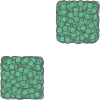

In [12]:
datos_simples_0.get_Multypoint()

Generamos un objeto para agrupar las cosas con distintos algoritmos

In [13]:
cluster_all  = Clusters(datos_simples_0)

In [14]:
cluster_all.OPTICS()
cluster_all.HDBSCAN()
cluster_all.DBSCAN(eps=0.1, min_samples=10)
cluster_all.KMeans()

/home/miguel/conda_previus/envs/nbdev_prueba_2026/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


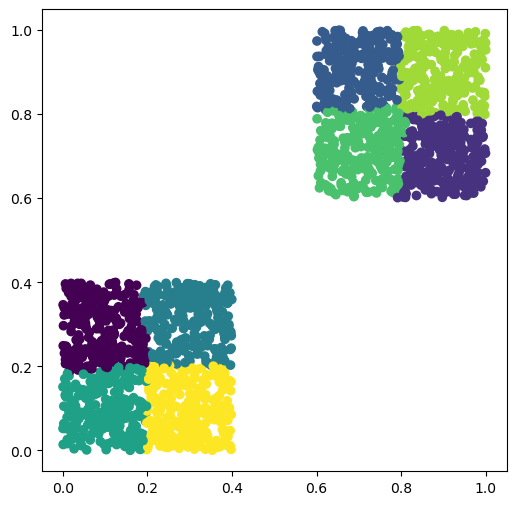

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_Kmeans
)

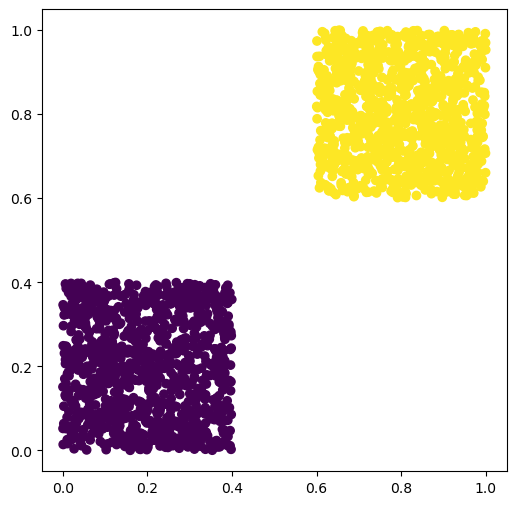

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_DBSCAN
)


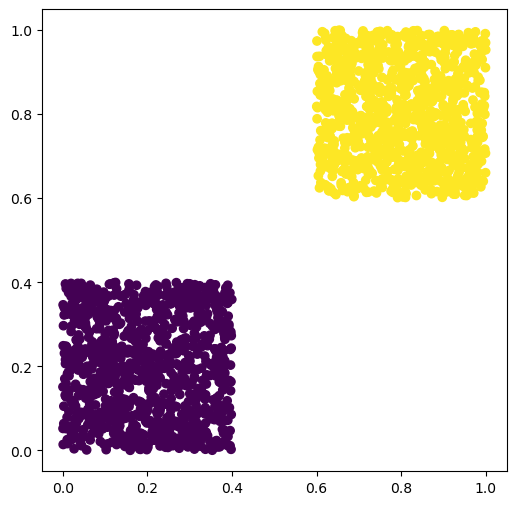

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_HDBSCAN
)

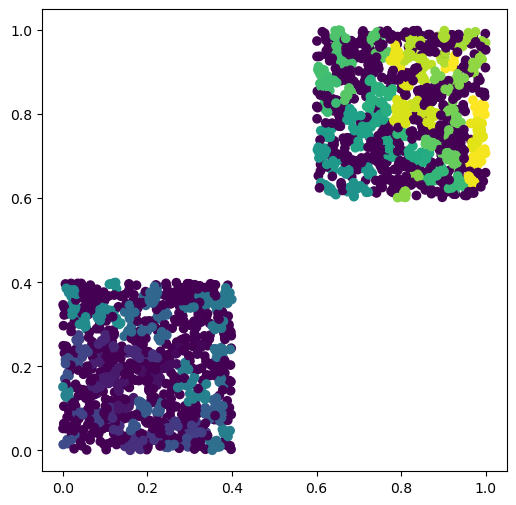

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(
cluster_all.data_structure.get_X(),
cluster_all.data_structure.get_Y(),
c=cluster_all.data_structure.classes_OPTICS
)

In [19]:
#| hide
import nbdev; nbdev.nbdev_export()